In [204]:
import pandas as pd 
import numpy as np
from datetime import datetime, timedelta
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split



In [205]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
data.drop(columns=['API_UserName','observations','day','month'], inplace=True)
# Ensure the 'date' column is in datetime format
data['date'] = pd.to_datetime(data['date'])
#data = data[data['indicator'] == '46.246.8.21']
data.tail(300)

,date,indicator,dayofweek,is_weekend,seen
22212,2025-04-21,23.26.221.24,0,False,0
22213,2025-04-21,23.26.221.26,0,False,0
22214,2025-04-21,46.246.8.46,0,False,0
22215,2025-04-21,46.246.8.56,0,False,0
22216,2025-04-21,46.246.8.96,0,False,0
...,...,...,...,...,...
22507,2025-04-22,107.180.119.251,1,False,0
22508,2025-04-22,190.92.174.36,1,False,0
22509,2025-04-22,192.124.249.112,1,False,0
22510,2025-04-22,66.132.159.247,1,False,0


In [206]:
# Ensure the data is sorted by 'indicator' and 'date'
data = data.sort_values(['indicator', 'date']).reset_index(drop=True)

# Initialize the 'days_since_last_seen' column with default values
data['days_since_last_seen'] = np.nan

# Calculate days since 'seen' was last equal to 1 for each indicator
for indicator, group in data.groupby('indicator'):
    # Filter rows where 'seen' is 1
    seen_dates = group[group['seen'] == 1]['date']
    
    # Calculate the difference in days for each row
    group['days_since_last_seen'] = group['date'].apply(
        lambda x: (x - seen_dates[seen_dates < x].max()).days if not seen_dates[seen_dates < x].empty else np.nan
    )
    
    # Update the main DataFrame
    data.loc[group.index, 'days_since_last_seen'] = group['days_since_last_seen']

# Fill NaN values with 0 (e.g., for the first occurrence of each indicator)
data['days_since_last_seen'] = data['days_since_last_seen'].fillna(0).astype(int)

# Add exponentially weighted mean of past activity (ewm_seen)
data['ewm_seen'] = data.groupby('indicator')['seen'].apply(lambda x: x.ewm(span=3, adjust=False).mean()).reset_index(drop=True)

# Add rolling count of 'seen == 1' in the last 3 days (seen_count_last_3)
data['seen_count_last_3'] = data.groupby('indicator')['seen'].apply(lambda x: x.rolling(window=3, min_periods=1).sum()).reset_index(drop=True)

In [207]:
data['date'] = pd.to_datetime(data['date'])
test_data = data[data['date'] == '2025-04-22 00:00:00']
#cutoff data 7 days ago and on
cutoff_date = datetime.now() - timedelta(days=7)
modelData = data[data['date'] <= cutoff_date]
modelData = modelData.sort_values(['indicator', 'date']).reset_index(drop=True)

In [208]:
modelData[modelData['indicator'] == '102.129.153.43']

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3
105,2025-01-01,102.129.153.43,2,False,0,0,0.000000e+00,0.0
106,2025-01-02,102.129.153.43,3,False,0,0,0.000000e+00,0.0
107,2025-01-03,102.129.153.43,4,False,0,0,0.000000e+00,0.0
108,2025-01-04,102.129.153.43,5,True,0,0,0.000000e+00,0.0
109,2025-01-05,102.129.153.43,6,True,0,0,0.000000e+00,0.0
...,...,...,...,...,...,...,...,...
205,2025-04-11,102.129.153.43,4,False,0,38,1.818991e-12,0.0
206,2025-04-12,102.129.153.43,5,True,0,39,9.094956e-13,0.0
207,2025-04-13,102.129.153.43,6,True,0,40,4.547478e-13,0.0
208,2025-04-14,102.129.153.43,0,False,0,41,2.273739e-13,0.0


In [209]:
print(f"X_train shape: {X_train.shape}")  # Should be (samples, timesteps, features)
print(f"y_train shape: {y_train.shape}")  # Should be (samples,)

X_train shape: (14472, 91, 1)
y_train shape: (14472,)


In [210]:
test_data

,date,indicator,dayofweek,is_weekend,seen,days_since_last_seen,ewm_seen,seen_count_last_3
111,2025-04-22,102.129.153.158,1,False,0,25,1.490117e-08,0.0
223,2025-04-22,102.129.153.43,1,False,0,49,8.881793e-16,0.0
335,2025-04-22,102.129.153.71,1,False,0,5,1.562500e-02,0.0
447,2025-04-22,102.165.16.161,1,False,0,12,1.223125e-04,0.0
559,2025-04-22,104.160.6.2,1,False,0,40,4.547474e-13,0.0
...,...,...,...,...,...,...,...,...
22063,2025-04-22,international.standardbank.com/,1,False,0,91,2.019484e-28,0.0
22175,2025-04-22,pub.marq.com/,1,False,0,12,1.245812e-04,0.0
22287,2025-04-22,realinvestmentadvice.com/,1,False,0,11,2.613068e-04,0.0
22399,2025-04-22,www.emergencylighting.com/,1,False,0,69,1.270601e-21,0.0


In [211]:
# Generate sequences with 15 lags, including all features
sequences = []
window = 15

for indicator, group in modelData.groupby("indicator"):
    group = group.sort_values("date").reset_index(drop=True)
    for i in range(len(group) - window):
        seq = group.iloc[i:i+window][['seen', 'dayofweek', 'is_weekend', 'days_since_last_seen', 'ewm_seen', 'seen_count_last_3']].values
        label = group['seen'].iloc[i+window]
        date = group['date'].iloc[i+window]  # Get the date corresponding to the label
        sequences.append({
            'date': date,  # Add the date here
            'label': label,
            'indicator': indicator,
            **{f'lag_{j+1}_seen': val[0] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_dayofweek': val[1] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_is_weekend': val[2] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_days_since_last_seen': val[3] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_ewm_seen': val[4] for j, val in enumerate(seq)},
            **{f'lag_{j+1}_seen_count_last_3': val[5] for j, val in enumerate(seq)}
        })

# Convert sequences to a DataFrame
sequence_df = pd.DataFrame(sequences)

# Save the DataFrame to a CSV file
sequence_df.to_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv", index=False)

In [212]:
sequence_df.head(500)

,date,label,indicator,lag_1_seen,lag_2_seen,lag_3_seen,lag_4_seen,lag_5_seen,lag_6_seen,lag_7_seen,...,lag_6_seen_count_last_3,lag_7_seen_count_last_3,lag_8_seen_count_last_3,lag_9_seen_count_last_3,lag_10_seen_count_last_3,lag_11_seen_count_last_3,lag_12_seen_count_last_3,lag_13_seen_count_last_3,lag_14_seen_count_last_3,lag_15_seen_count_last_3
0,2025-01-16,0,102.129.153.158,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-01-17,0,102.129.153.158,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-01-18,0,102.129.153.158,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-01-19,0,102.129.153.158,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-01-20,0,102.129.153.158,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2025-03-02,1,104.18.32.191,0,0,0,1,1,0,0,...,2.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
496,2025-03-03,0,104.18.32.191,0,0,1,1,0,0,0,...,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,2.0
497,2025-03-04,0,104.18.32.191,0,1,1,0,0,0,0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,2.0,2.0
498,2025-03-05,0,104.18.32.191,1,1,0,0,0,0,0,...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,2.0,2.0,1.0


In [213]:
sequence_df[sequence_df['indicator'] == '102.129.153.43']

,date,label,indicator,lag_1_seen,lag_2_seen,lag_3_seen,lag_4_seen,lag_5_seen,lag_6_seen,lag_7_seen,...,lag_6_seen_count_last_3,lag_7_seen_count_last_3,lag_8_seen_count_last_3,lag_9_seen_count_last_3,lag_10_seen_count_last_3,lag_11_seen_count_last_3,lag_12_seen_count_last_3,lag_13_seen_count_last_3,lag_14_seen_count_last_3,lag_15_seen_count_last_3
90,2025-01-16,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91,2025-01-17,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
92,2025-01-18,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
93,2025-01-19,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
94,2025-01-20,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2025-04-11,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
176,2025-04-12,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177,2025-04-13,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
178,2025-04-14,0,102.129.153.43,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [214]:
# Check data types
print(modelData.dtypes)

# Convert 'seen' column to numeric if necessary
modelData['seen'] = pd.to_numeric(modelData['seen'], errors='coerce')

# Ensure 'date' column is in datetime format
modelData['date'] = pd.to_datetime(modelData['date'], errors='coerce')

date                    datetime64[ns]
indicator                       object
dayofweek                        int64
is_weekend                        bool
seen                             int64
days_since_last_seen             int64
ewm_seen                       float64
seen_count_last_3              float64
dtype: object


In [215]:
# Load processed data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\data\sequence_data_for_lstm.csv")
X = df.drop(columns=['label', 'indicator']).values
y = df['label'].values
indicators = df['indicator'].values

X = df.drop(columns=['label', 'indicator'])

# Strip column names (just in case)
X.columns = X.columns.str.strip()

# Coerce all data to numeric, fill missing, then convert to numpy
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32).values

# Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train/test split
X_train, X_test, y_train, y_test, ind_train, ind_test = train_test_split(
    X, y, indicators, test_size=0.2, random_state=42
)

# Define an improved LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Lower LR for better convergence
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Add early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop]
)


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 112s 73ms/step - accuracy: 0.7766 - loss: 0.5227 - val_accuracy: 0.9064 - val_loss: 0.3485
Epoch 2/60
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 94s 65ms/step - accuracy: 0.8966 - loss: 0.3225 - val_accuracy: 0.9050 - val_loss: 0.2849
Epoch 3/60
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 107s 74ms/step - accuracy: 0.9012 - loss: 0.3114 - val_accuracy: 0.8957 - val_loss: 0.3325
Epoch 4/60
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 126s 87ms/step - accuracy: 0.9057 - loss: 0.2956 - val_accuracy: 0.9064 - val_loss: 0.2993
Epoch 5/60
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 139s 96ms/step - accuracy: 0.9040 - loss: 0.3009 - val_accuracy: 0.9057 - val_loss: 0.2935
Epoch 6/60
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 108s 74ms/step - accuracy: 0.9055 - loss: 0.3026 - val_accuracy: 0.9067 - val_loss: 0.3051
Epoch 7/60
1448/1448 ━━━━━━━━━━━━━━━━━━━━ 100s 69ms/step - accuracy: 0.9031 - loss: 0.2999 - val_accuracy: 0.9060 - val_loss: 0.3078


In [253]:
# Predict on test set
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# Group by indicator and calculate stats
from collections import defaultdict

indicator_stats = defaultdict(lambda: {'true': [], 'pred': [], 'prob': []})
for i, ind in enumerate(ind_test):
    indicator_stats[ind]['true'].append(y_test[i])
    indicator_stats[ind]['pred'].append(y_pred[i])
    indicator_stats[ind]['prob'].append(y_pred_prob[i])

# Build summary
summary = []
for ind, vals in indicator_stats.items():
    acc = np.mean(np.array(vals['true']) == np.array(vals['pred']))
    avg_prob = np.mean(vals['prob'])
    date = data[data['indicator'] == ind]['date'].values[0] if ind in data['indicator'].values else np.nan
    summary.append({
        'indicator': ind,
        'accuracy': round(acc, 3),
        'avg_predicted_probability': round(avg_prob, 3),
        'samples': len(vals['true']),
        'seen': test_data[test_data['indicator'] == ind]['seen'].values[0]
    })

results_df = pd.DataFrame(summary).sort_values(by='avg_predicted_probability', ascending=False)
results_df.head(500)


114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


,indicator,accuracy,avg_predicted_probability,samples,seen
126,34.160.111.145,0.917,0.818,12,0
72,172.240.108.68,0.833,0.772,18,1
67,162.142.125.247,0.750,0.742,16,0
158,162.142.125.242,0.800,0.729,15,1
4,185.230.63.171,0.733,0.680,15,1
...,...,...,...,...,...
164,190.92.174.92,0.917,0.025,12,0
182,176.113.74.89,1.000,0.025,19,0
180,190.92.174.48,0.947,0.025,19,0
189,20.48.204.4,1.000,0.025,15,0


In [217]:
# Extract the indicators from both dataframes
results_indicators = set(results_df['indicator'])
test_data_indicators = set(test_data['indicator'])

# Find matching indicators
matching_indicators = results_indicators.intersection(test_data_indicators)

# Find missing indicators in test_data
missing_in_test_data = results_indicators.difference(test_data_indicators)

# Find missing indicators in sorted_results_df
missing_in_sorted_results = test_data_indicators.difference(results_indicators)

# Display the results
print("Matching Indicators:", matching_indicators)
print("Indicators in results_df but missing in test_data:", missing_in_test_data)
print("Indicators in test_data but missing in results_df:", missing_in_sorted_results)

Matching Indicators: {'77.75.73.61', '156.146.63.168', '61.95.255.74', '146.70.204.179', '156.146.63.164', '46.246.8.131', '156.146.63.171', '15.235.218.150', '23.26.221.5', '162.142.125.247', '84.239.47.7', '72.21.210.29', '23.205.105.180', '156.146.63.181', '23.26.221.7', '34.160.111.145', '113.96.236.11', '23.26.221.13', '102.129.153.158', '66.132.159.244', '62.233.57.136', '88.119.174.148', '23.26.221.20', '178.175.129.37', '68.67.179.164', '46.246.8.75', '156.146.63.131', '23.26.221.10', '5.79.110.170', '146.71.50.198', '23.26.221.21', '74.119.239.234', '64.64.112.146', '185.230.63.171', '192.124.249.112', '156.146.63.177', 'pub.marq.com/', '162.241.216.236', '162.142.125.255', '46.246.8.84', '156.146.63.167', '79.98.104.4', '46.246.8.91', '46.246.8.15', '46.246.8.29', '46.246.8.102', '46.246.8.136', '23.26.221.2', 'www.shorturl.at/', '46.246.8.116', '64.64.112.131', '156.146.63.175', '84.239.31.15', '46.246.8.133', '156.146.63.133', '107.180.119.251', '46.246.8.34', '23.26.221.18

In [218]:
results_df.columns

Index(['indicator', 'accuracy', 'avg_predicted_probability', 'samples',
       'seen'],
      dtype='object')


=== Aggregated Threshold Usage Across All Indicators ===
Threshold 0.4: avg_reward=0.853, used 466x
Threshold 0.5: avg_reward=0.875, used 428x
Threshold 0.6: avg_reward=0.889, used 429x
Threshold 0.7: avg_reward=0.896, used 412x


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


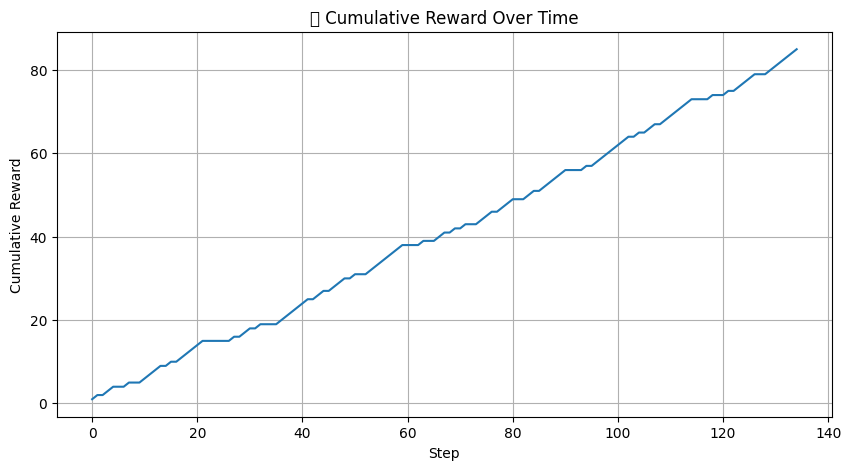

C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


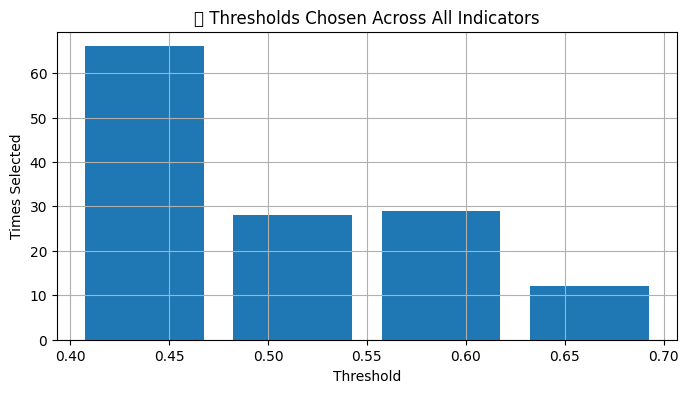

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Bandit threshold options
actions = [0.4, 0.5, 0.6, 0.7]
epsilon = 0.1  # 10% exploration

# Per-indicator bandit state
bandits = {}

# Logging
reward_log = []
threshold_log = []
actual_outcomes = []

# ✅ Warm-start bandit with historical LSTM accuracy
def choose_action(indicator):
    if indicator not in bandits:
        historical_info = results_df[results_df['indicator'] == indicator]
        if not historical_info.empty:
            global_accuracy_for_indicator = historical_info['accuracy'].values[0]
        else:
            global_accuracy_for_indicator = 0.5  # neutral default

        initial_reward = global_accuracy_for_indicator * 10
        bandits[indicator] = {
            'rewards': np.array([initial_reward] * len(actions)),
            'counts': np.array([10] * len(actions))
        }

    rewards = bandits[indicator]['rewards']
    counts = bandits[indicator]['counts']

    if np.random.rand() < epsilon:
        return np.random.choice(len(actions))  # explore
    else:
        return np.argmax(rewards / (counts + 1e-5))  # exploit

# ✅ Update reward
def update_rewards(indicator, action, reward):
    bandits[indicator]['counts'][action] += 1
    bandits[indicator]['rewards'][action] += reward

# ✅ Step 1: LSTM Confidence-Based Filtering
HIGH_CONF = 0.5
LOW_CONF = 0.3

indicators_to_exclude = results_df[
    ((results_df['avg_predicted_probability'] >= HIGH_CONF) & (results_df['seen'] == 1)) |
    ((results_df['avg_predicted_probability'] < LOW_CONF) & (results_df['seen'] == 0))
]['indicator'].unique()

filtered_indicators = results_df

filtered_indices = [
    i for i, ind in enumerate(filtered_indicators)
    if i < len(y_pred_prob) and ind not in indicators_to_exclude
]

# ✅ Step 2: Run Bandit Evaluation Only on Remaining
for i in filtered_indices:
    indicator = indicators[i]
    prob = y_pred_prob[i]
    action = choose_action(indicator)
    threshold = actions[action]

    # Predict
    prediction = 1 if prob > threshold else 0

    # Lookup actual
    seen_today = test_data[test_data['indicator'] == indicator]['seen']
    actual = int(seen_today.values[0]) if not seen_today.empty else 0

    reward = 1 if prediction == actual else 0
    update_rewards(indicator, action, reward)

    reward_log.append(reward)
    threshold_log.append(threshold)
    actual_outcomes.append({
        'indicator': indicator,
        'predicted_prob': prob,
        'threshold': threshold,
        'predicted': prediction,
        'actual': actual,
        'reward': reward
    })

# ✅ Optional Stats & Plots
print("\n=== Aggregated Threshold Usage Across All Indicators ===")
aggregated_counts = np.zeros(len(actions))
aggregated_rewards = np.zeros(len(actions))

for bandit in bandits.values():
    aggregated_counts += bandit['counts']
    aggregated_rewards += bandit['rewards']

avg_rewards = aggregated_rewards / (aggregated_counts + 1e-5)
for a, r, c in zip(actions, avg_rewards, aggregated_counts):
    print(f"Threshold {a}: avg_reward={r:.3f}, used {int(c)}x")

# 🎯 Plot cumulative reward
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(reward_log))
plt.title("🎯 Cumulative Reward Over Time")
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.show()

# 🧠 Plot threshold usage
plt.figure(figsize=(8, 4))
plt.hist(threshold_log, bins=len(actions), rwidth=0.8)
plt.title("🧠 Thresholds Chosen Across All Indicators")
plt.xlabel("Threshold")
plt.ylabel("Times Selected")
plt.grid(True)
plt.show()


In [257]:
print(f"Length of y_pred_prob: {len(y_pred_prob)}")
print(f"Length of indicators: {len(indicators)}")

Length of y_pred_prob: 3618
Length of indicators: 18090


In [258]:
results_df = pd.DataFrame(actual_outcomes)
results_df

,indicator,predicted_prob,threshold,predicted,actual,reward
0,102.129.153.158,0.098203,0.4,0,0,1
1,102.129.153.158,0.186964,0.4,0,0,1
2,102.129.153.158,0.639474,0.4,1,0,0
3,102.129.153.43,0.239746,0.4,0,0,1
4,102.129.153.71,0.024563,0.6,0,0,1
...,...,...,...,...,...,...
130,156.146.63.174,0.224648,0.6,0,0,1
131,156.146.63.174,0.024532,0.6,0,0,1
132,156.146.63.174,0.024643,0.6,0,0,1
133,156.146.63.174,0.289921,0.6,0,0,1


In [ ]:
bandit_results_df = pd.DataFrame(actual_outcomes)
# Step 2: Group and summarize per indicator
results_summary = bandit_results_df.groupby("indicator").agg(
    total_predictions=('predicted', 'count'),
    times_predicted_seen=('predicted', 'sum'),
    times_actually_seen=('actual', 'sum'),
    correct_predictions=('reward', 'sum'),
    accuracy=('reward', 'mean'),
    avg_predicted_prob=('predicted_prob', 'mean'),
    avg_threshold=('threshold', 'mean'),
).reset_index().sort_values(by='accuracy', ascending=False)

# Step 3: Preview the summary
results_summary


,indicator,total_predictions,times_predicted_seen,times_actually_seen,correct_predictions,accuracy,avg_predicted_prob,avg_threshold
22,15.235.218.150,90,0,0,90,1.000000,0.107433,0.406667
27,156.146.63.162,90,1,0,89,0.988889,0.104432,0.488889
35,156.146.63.170,90,1,0,89,0.988889,0.088913,0.450000
28,156.146.63.163,90,1,0,89,0.988889,0.091848,0.484444
0,102.129.153.158,90,2,0,88,0.977778,0.103306,0.692222
16,146.71.50.198,90,2,0,88,0.977778,0.109801,0.453333
11,107.180.119.251,90,2,0,88,0.977778,0.105943,0.537778
19,149.36.49.225,90,2,0,88,0.977778,0.108823,0.565556
25,156.146.63.132,90,2,0,88,0.977778,0.111458,0.583333
32,156.146.63.167,90,2,0,88,0.977778,0.103301,0.438889


In [239]:
best_thresholds = {
    ind: actions[np.argmax(data['rewards'] / (data['counts'] + 1e-5))]
    for ind, data in bandits.items()
}

actual_outcomes_final = []

for i in filtered_indices:
    indicator = indicators[i]
    prob = y_pred_prob[i]

    # Get threshold from bandit
    threshold = best_thresholds.get(indicator, 0.5)
    prediction = 1 if prob > threshold else 0

    # Get actual label
    seen_today = test_date_full[test_date_full['indicator'] == indicator]['seen']
    actual = int(seen_today.values[0]) if not seen_today.empty else 0

    actual_outcomes_final.append({
        'indicator': indicator,
        'predicted_prob': prob,
        'threshold': threshold,
        'predicted': prediction,
        'actual': actual,
        'correct': int(prediction == actual)
    })

final_results_df = pd.DataFrame(actual_outcomes_final)
final_results_df

IndexError: index 3618 is out of bounds for axis 0 with size 3618

In [ ]:
# Condense to one row per indicator
condensed_results = final_results_df.groupby("indicator").agg({
    'predicted_prob': 'mean',       # Average predicted probability
    'threshold': 'mean',            # Average threshold used (should be same if static per indicator)
    'predicted': 'sum',             # Number of times predicted as seen
    'actual': 'sum',                # Number of times actually seen
    'correct': ['sum', 'mean'],     # Total correct, and accuracy
    'indicator': 'count'            # Total predictions made
})

# Flatten the multi-index columns
condensed_results.columns = [
    'avg_predicted_prob', 'avg_threshold',
    'predicted_seen', 'actual_seen',
    'correct_predictions', 'accuracy',
    'total_predictions'
]
condensed_results = condensed_results.reset_index()
condensed_results

,indicator,avg_predicted_prob,avg_threshold,predicted_seen,actual_seen,correct_predictions,accuracy,total_predictions
0,102.129.153.158,0.103306,0.5,3,0,87,0.966667,90
1,102.129.153.43,0.124602,0.4,6,0,84,0.933333,90
2,102.129.153.71,0.110938,0.7,3,0,87,0.966667,90
3,102.165.16.161,0.107180,0.7,2,0,88,0.977778,90
4,104.160.6.2,0.118214,0.7,4,0,86,0.955556,90
5,104.18.32.191,0.111437,0.6,2,0,88,0.977778,90
6,104.21.3.76,0.124618,0.5,4,0,86,0.955556,90
7,104.21.47.124,0.140539,0.7,7,0,83,0.922222,90
8,104.21.48.1,0.099488,0.6,1,90,1,0.011111,90
9,104.21.54.132,0.118489,0.5,3,0,87,0.966667,90


In [ ]:
condensed_results[condensed_results['indicator'] == '185.230.63.171']

,indicator,avg_predicted_prob,avg_threshold,predicted_seen,actual_seen,correct_predictions,accuracy,total_predictions
